In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
from pathlib import Path

FIG_DIR = Path("figures")

In [2]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 3 * 3, 1024)
        self.fc2 = nn.Linear(1024, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # raw logits; F.cross_entropy applies softmax internally

In [3]:
BATCH_SIZE = 64
N_STEPS = 6000
EVAL_INTERVAL = 100
N_SEEDS = 3 # Real thing use 10
BETA = 0.9

# Best step sizes from Balles & Hennig (2018), Appendix A
ALPHA = {
    'M-SGD':  0.1,
    'Adam':   1e-3,
    'M-SSD':  3e-4,
    'M-SVAG': 0.3,
}

transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_data  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
class MSGD(torch.optim.Optimizer):
    """Momentum SGD with bias-corrected first moment (Balles & Hennig 2018)."""
    def __init__(self, params, lr, beta=0.9):
        super().__init__(params, dict(lr=lr, beta=beta))

    def step(self, closure=None):
        for group in self.param_groups:
            lr, beta = group['lr'], group['beta']
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(p.data)
                state['step'] += 1
                state['m'].mul_(beta).add_(p.grad, alpha=1 - beta)
                m_hat = state['m'] / (1 - beta ** state['step'])
                p.data.add_(m_hat, alpha=-lr)


class MSSD(torch.optim.Optimizer):
    """Momentum sign descent: update by sign of EMA gradient (Balles & Hennig 2018)."""
    def __init__(self, params, lr, beta=0.9):
        super().__init__(params, dict(lr=lr, beta=beta))

    def step(self, closure=None):
        for group in self.param_groups:
            lr, beta = group['lr'], group['beta']
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:
                    state['m'] = torch.zeros_like(p.data)
                state['m'].mul_(beta).add_(p.grad, alpha=1 - beta)
                p.data.add_(state['m'].sign(), alpha=-lr)


class MSVAG(torch.optim.Optimizer):
    """Variance-adapted momentum SGD without sign (Balles & Hennig 2018, Alg. 2).

    Update: θ ← θ − α (γ ⊙ m)  where γ = m² / (m² + ρ·s) is an SNR-based gate
    and s = (v − m²) / (1 − ρ) is the bias-corrected gradient variance estimate.
    """
    def __init__(self, params, lr, beta=0.9, eps=1e-8):
        super().__init__(params, dict(lr=lr, beta=beta, eps=eps))

    def step(self, closure=None):
        for group in self.param_groups:
            lr, beta, eps = group['lr'], group['beta'], group['eps']
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(p.data)
                    state['v'] = torch.zeros_like(p.data)
                state['step'] += 1
                t = state['step']

                g = p.grad
                state['m'].mul_(beta).add_(g, alpha=1 - beta)
                state['v'].mul_(beta).add_(g.pow(2), alpha=1 - beta)

                bias_corr = 1 - beta ** t
                m = state['m'] / bias_corr
                v = state['v'] / bias_corr

                # ρ(β, t) = (1−β)(1+β^(t+1)) / ((1+β)(1−β^(t+1)))
                # with β^(t+1) = beta**t in 1-indexed step notation
                rho = (1 - beta) * (1 + beta ** t) / ((1 + beta) * bias_corr)
                s = (v - m.pow(2)).clamp(min=0) / (1 - rho + eps)
                gamma = m.pow(2) / (m.pow(2) + rho * s + eps)
                p.data.add_(gamma * m, alpha=-lr)

In [5]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


def make_optimizer(name, params):
    if name == 'M-SGD':
        return MSGD(params, lr=ALPHA['M-SGD'], beta=BETA)
    if name == 'M-SSD':
        return MSSD(params, lr=ALPHA['M-SSD'], beta=BETA)
    if name == 'M-SVAG':
        return MSVAG(params, lr=ALPHA['M-SVAG'], beta=BETA)
    if name == 'Adam':
        return torch.optim.Adam(params, lr=ALPHA['Adam'], betas=(0.9, 0.999), eps=1e-8)


def run_one(seed, method_name):
    set_seed(seed)
    model = CNN().to(device)
    optimizer = make_optimizer(method_name, model.parameters())
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    train_iter = iter(loader)
    accs = []

    model.train()
    for step in range(N_STEPS):
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(loader)
            x, y = next(train_iter)
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        criterion(model(x), y).backward()
        optimizer.step()

        if (step + 1) % EVAL_INTERVAL == 0:
            accs.append(evaluate(model, test_loader, device))
            model.train()

    return accs

In [6]:
results = {}
eval_steps = list(range(EVAL_INTERVAL, N_STEPS + 1, EVAL_INTERVAL))

for method in ['M-SGD', 'Adam', 'M-SSD', 'M-SVAG']:
    print(f"\n=== {method} (α={ALPHA[method]}) ===")
    t0 = time.time()
    seed_accs = []
    for seed in range(N_SEEDS):
        accs = run_one(seed, method)
        seed_accs.append(accs)
        print(f"  seed {seed:2d}: final acc = {accs[-1]*100:.2f}%")
    results[method] = np.array(seed_accs)
    print(f"  elapsed: {time.time() - t0:.0f}s")


=== M-SGD (α=0.1) ===
  seed  0: final acc = 89.47%
  seed  1: final acc = 89.58%
  seed  2: final acc = 89.47%
  elapsed: 385s

=== Adam (α=0.001) ===
  seed  0: final acc = 90.61%
  seed  1: final acc = 90.34%
  seed  2: final acc = 90.31%
  elapsed: 393s

=== M-SSD (α=0.0003) ===
  seed  0: final acc = 89.98%
  seed  1: final acc = 89.84%
  seed  2: final acc = 90.33%
  elapsed: 383s

=== M-SVAG (α=0.3) ===
  seed  0: final acc = 89.83%
  seed  1: final acc = 90.00%
  seed  2: final acc = 88.86%
  elapsed: 411s


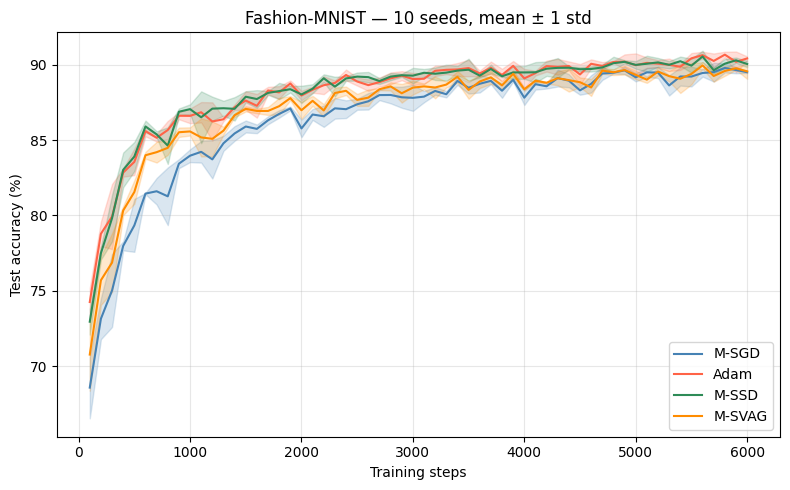

In [7]:
colors = {'M-SGD': 'steelblue', 'Adam': 'tomato', 'M-SSD': 'seagreen', 'M-SVAG': 'darkorange'}

fig, ax = plt.subplots(figsize=(8, 5))
for method, accs in results.items():
    mean = accs.mean(axis=0) * 100
    std  = accs.std(axis=0) * 100
    ax.plot(eval_steps, mean, label=method, color=colors[method])
    ax.fill_between(eval_steps, mean - std, mean + std, alpha=0.2, color=colors[method])

ax.set_xlabel('Training steps')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Fashion-MNIST — 10 seeds, mean ± 1 std')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fashion_mnist_comparison.pdf', bbox_inches='tight')
plt.show()